In [5]:
#data format library
import h5py

#numpy
import numpy as np
import pandas as pd
import numpy.ma as ma
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
# %matplotlib notebook
import sys
sys.path.append('./utils/')
import os
import copy
import partitioning_methods as cl
import operator_calculations as op_calc
import delay_embedding as embed
import stats
import time
from scipy.sparse import csr_matrix


In [6]:
path_to_filtered_data = '/flash/StephensU/Gautam/Multiscale_phenotypic_variation/Results/bacteria_all/'
D_int = np.load(path_to_filtered_data + 'D_int.npy')

In [11]:
f = h5py.File(path_to_filtered_data + 'bacteria_all_data.h5','r')
# X = np.array(f['X'])
# bacteria_indices = np.array(f['bacteria_indices'])
print(f.keys())
bacteria_idx_all = np.array(f['MetaData/bacteria_idx_all'],dtype=int)
X = np.array(f['X_all'])
diffcoeff = np.array(f['diffcoeff'])
dpsi_all = np.array(f['dpsi_all'])
psi_all = np.array(f['psi_all'])
speed_all = np.array(f['runspeeds'])
meanruntime = ma.masked_invalid(np.array(f['meanruntime']))
msd_all = np.array(f['msd_all'])
tbias = np.array(f['tbias'])
yfp_cheb = ma.masked_invalid(np.array(f['yfp_cheb']))
rfp_cher = ma.masked_invalid(np.array(f['rfp_cher']))
f.close()

yfp_cheb[yfp_cheb==0]=ma.masked
rfp_cher[rfp_cher==0]=ma.masked

X = ma.masked_invalid(X)
X[X==0]=ma.masked
dpsi_all=ma.masked_invalid(dpsi_all)
dpsi_all[dpsi_all==0]=ma.masked
psi_all=ma.masked_invalid(psi_all)
psi_all[psi_all==0]=ma.masked
speed_all=ma.masked_invalid(speed_all)
speed_all[speed_all==0]=ma.masked
meanruntime[meanruntime==0]=ma.masked

np.where(np.diff(bacteria_idx_all)<-100)
dataset_idx = np.zeros((bacteria_idx_all.shape[0],))
dataset_idx[np.where(np.diff(bacteria_idx_all)<-100)[0][0]+1:] = 1.

<KeysViewHDF5 ['MetaData', 'X_all', 'diffcoeff', 'dpsi_all', 'feats', 'meanruntime', 'msd_all', 'psi_all', 'rfp_cher', 'runspeeds', 'speeds_all', 'tbias', 'yfp_cheb']>


In [12]:
from numpy.linalg import matrix_power
from scipy.sparse.linalg import eigs,eigsh
from numba import njit, prange
import numpy as np

# k_sigma = int(D_int.shape[0]/20)
k_sigma=600
sorted_d = np.sort(D_int, axis=1)
sigma = np.zeros(len(D_int))
for i in range(len(D_int)):
    nonzero = sorted_d[i, sorted_d[i] > 0]
    if len(nonzero) >= k_sigma:
        sigma[i] = nonzero[k_sigma - 1]
    else:
        sigma[i] = nonzero[-1] if len(nonzero) > 0 else 1.0  # fallback
        

sigma_mat = np.outer(sigma, sigma)
kern = np.exp(-D_int**2 / sigma_mat) 

qa = kern.sum(axis=0) ** -1
Da = np.diag(qa)
L = np.dot(Da, np.dot(kern, Da))
M = np.dot(np.diag(np.sum(L, axis=1) ** -1), L)

M = op_calc.get_reversible_transition_matrix(M)

n_modes = 100
diff_eig, diff_ev = eigs(M, k=n_modes+1,which='LR')
inv_measure = op_calc.stationary_distribution(M)

sorted_indices = np.argsort(diff_eig.real)[::-1]
diff_eig = diff_eig[sorted_indices].real
diff_ev = diff_ev[:, sorted_indices].real

diff_eigvecs = diff_ev / np.sqrt((diff_ev**2 * inv_measure[:, None]).sum(axis=0))
# diff_eigvecs = diff_ev/np.linalg.norm(diff_ev,axis=0)


phis = diff_eigvecs[:, 1:]           
eigs_nontrivial = diff_eig[1:]      

Xp = phis * eigs_nontrivial[None, :]  

In [9]:
#flip axis to match
if Xp[:,0].max()>-Xp[:,0].min():
    Xp[:,0] = -Xp[:,0]
if Xp[:,1].max()<-Xp[:,1].min():
    Xp[:,1] = -Xp[:,1]

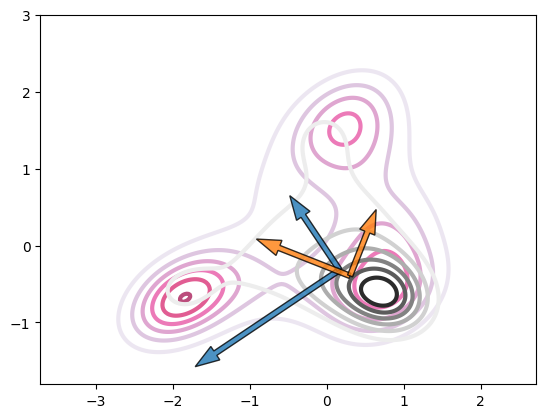

In [17]:
from scipy.stats import gaussian_kde
cmaps = ['PuRd','Greys']
fig, ax = plt.subplots(1,1)
for i in [0,1]:
    idx = np.where(dataset_idx == i)[0]
    values = Xp[idx,:2].T
    kernel = gaussian_kde(values,bw_method=0.4)
    X,Y = np.meshgrid(np.linspace(-3,2,200),np.linspace(-1.5,3,200))
    positions = np.vstack([X.ravel(), Y.ravel()])
    img = np.reshape(kernel(positions).T, X.shape)
    if i == 0:
        plt.contour(X,Y, img, cmap=cmaps[int(i)], linewidths=3,alpha=0.7)
    else:
        plt.contour(X,Y, img, cmap=cmaps[int(i)], linewidths=3)
    
    # img = stats.density_plot(diff_dists[idx,1], diff_dists[idx,2],[-0.04,0.02],[-0.02,0.03],70,70,smooth=True, border=3)
    # X,Y = np.meshgrid(np.linspace(-0.04,0.02,76),np.linspace(-0.02,0.03,76))
    # plt.contour(X,Y, img, cmap=cmaps[int(i)], linewidths=3)

    X = Xp[idx,:2]
    X = X - np.mean(X,axis=0)
    cov = np.cov(X.T)
    e1, ev2 = np.linalg.eig(cov)
    ms = np.median(Xp[idx,:2],axis=0)
    plt.arrow(ms[0],ms[1], -1*1.5*e1[0]*ev2[0,0], -1*1.5*e1[0]*ev2[1,0], width = 0.07, alpha=0.8, ec='k',zorder=10,color = 'C{}'.format(i))
    plt.arrow(ms[0],ms[1], 1.5*e1[1]*ev2[0,1], 1.5*e1[1]*ev2[1,1], width = 0.07, alpha=0.8, ec='k',zorder=10,color = 'C{}'.format(i))
    
    # plt.colorbar()
plt.axis('equal')
# plt.savefig(Fig_path+'dataset_densities.pdf')
plt.show()

In [9]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

def get_global_model_shuffled(X_fit,y_fit,n_boot=1000,kd_y=None):

    if kd_y is not None:
        y_fit = y_fit[:,kd_y].reshape(-1,1)
    kf = KFold(n_splits=5, shuffle=True, random_state=0)

    mses = []
    r2s  = []
    coefs=[]
    
    for train_idx, test_idx in kf.split(X_fit):
        model = LinearRegression().fit(X_fit[train_idx], y_fit[train_idx])
        y_pred = model.predict(X_fit[test_idx])
    
        mses.append(mean_squared_error(y_fit[test_idx], y_pred))
        r2s.append(r2_score(y_fit[test_idx], y_pred))
        coefs.append(model.coef_)
    
    mses = np.array(mses)   # shape (n_splits, 2)
    r2s_cv  = np.array(r2s)    # shape (n_splits, 2)


    model = LinearRegression().fit(X_fit, y_fit)
    y_pred = model.predict(X_fit)
    r2_full = r2_score(y_fit, y_pred)
    r2_fulls = np.zeros(n_boot)
    for i in range(n_boot):
        idx = np.random.randint(0,len(y_fit),len(y_fit))
        model = LinearRegression().fit(X_fit[idx], y_fit[idx])
        y_pred = model.predict(X_fit[idx])
        r2_fulls[i] = r2_score(y_fit[idx], y_pred)    
    
    print("MSE per output:", mses.mean(), "+/-", mses.std())
    print("R²  per output:", r2s_cv.mean(),  "+/-", r2s_cv.std())
    importance = []
    for kd in range(2):
        r2_means=[]
        for i in range(n_boot):
            
            X_shuffle = X_fit.copy()
            X_shuffle[:,kd] = X_fit[np.random.randint(0,len(X_shuffle),len(X_shuffle)),kd]
            
            model = LinearRegression().fit(X_shuffle, y_fit)
            y_pred = model.predict(X_shuffle)
            r2 = r2_score(y_fit, y_pred)
            r2_means.append(r2)
        importance.append(r2_full-np.array(r2_means))
    return mses,r2s_cv,coefs,np.array(importance),r2_full,r2_fulls


import numpy as np
from scipy.stats import spearmanr


def bootstrap_spearman_ci(
    y,
    X,
    n_boot=5000,
    confidence=0.95,
    random_state=None
):
    """
    Paired bootstrap confidence intervals for cross-correlations
    between columns of y and columns of X.

    Rows are assumed to be independent sampling units.
    """
    y = np.asarray(y)
    X = np.asarray(X)

    if y.ndim == 1:
        y = y[:, None]
    if X.ndim == 1:
        X = X[:, None]

    if y.shape[0] != X.shape[0]:
        raise ValueError("X and y must have the same number of rows.")

    n, p = y.shape
    q = X.shape[1]

    rng = np.random.default_rng(random_state)
    rho_boot = np.full((n_boot, p, q), np.nan)

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)

        for i in range(p):
            for j in range(q):
                rho_boot[b, i, j] = spearmanr(
                    y[idx, i],
                    X[idx, j],
                    nan_policy="omit"
                ).statistic

    alpha = 1 - confidence

    ci_low = np.nanpercentile(
        rho_boot, 100 * alpha / 2, axis=0
    )
    ci_high = np.nanpercentile(
        rho_boot, 100 * (1 - alpha / 2), axis=0
    )

    return ci_low, ci_high, rho_boot

In [10]:
X = ma.vstack([speed_all,tbias]).T

y =  ma.masked_invalid(Xp)
sel = np.logical_and(~np.any(X.mask,axis=1),~np.any(y.mask,axis=1))


X_fit = (X[sel]-X[sel].mean(axis=0))/X[sel].std(axis=0)
y_fit = y[sel,:2]

In [11]:
labels_X = ['speed','tbias']
labels_y = ['v1','v2']

In [12]:
mses,r2s_full,coefs,importance,r2_full,r2_fulls = get_global_model_shuffled(X_fit,y_fit,n_boot=100)
mean = importance.mean(axis=1)
cil = np.percentile(importance,2.5,axis=1)
ciu = np.percentile(importance,97.5,axis=1)

MSE per output: 0.26074555040194225 +/- 0.0076025786313539045
R²  per output: 0.5544344945286673 +/- 0.01535840931672443


In [13]:
r2_full,np.percentile(r2_fulls,2.5),np.percentile(r2_fulls,97.5)

(0.5555180227836289,
 np.float64(0.5462504412438066),
 np.float64(0.5669735292124317))

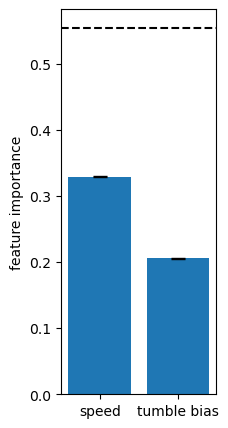

In [14]:
plt.figure(figsize=(2,5))
plt.bar(np.arange(len(mean)),mean,yerr = [mean-cil,ciu-mean],capsize=5)
plt.ylabel('feature importance')
plt.xticks([0,1],['speed','tumble bias'])
plt.axhline(r2_full,c='k',ls='--')
plt.ylim(0,)
# plt.savefig('feat_import_speed_tbias_phen.pdf')
plt.show()

In [ ]:
from scipy.stats import spearmanr


def fdr_bh(pvals):
    """Benjamini-Hochberg FDR correction."""
    p = np.asarray(pvals).ravel()
    order = np.argsort(p)
    p_sorted = p[order]
    m = len(p)

    # BH adjusted p-values
    q_sorted = np.minimum(p_sorted * m / np.arange(1, m + 1), 1.0)

    # enforce monotonicity
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]

    # put back in original order
    q = np.empty_like(q_sorted)
    q[order] = q_sorted
    return q.reshape(pvals.shape)


[[0.00000000e+000 0.00000000e+000]
 [2.71519014e-238 0.00000000e+000]]


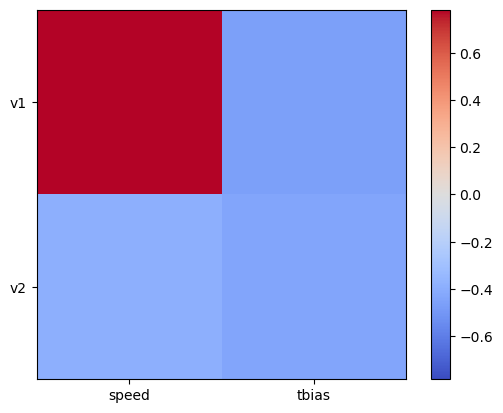

In [62]:
rho, pval = spearmanr(y_fit, X_fit, nan_policy='omit')

p = y_fit.shape[1]   # number of y variables
q = X_fit.shape[1]   # number of x variables

rho_cross = rho[:p, p:]
pval_cross = pval[:p, p:]

# Apply correction
pval_adj = fdr_bh(pval_cross)
print(pval_adj)

vmax = np.max(np.abs(rho_cross))
plt.imshow(rho_cross,vmax=vmax,vmin=-vmax,cmap='coolwarm')
plt.xticks([0,1],['speed','tbias'])
plt.yticks([0,1],['v1','v2'])
# for i in range(p):
    # for j in range(p):
        # plt.text(j-.1,i+.01,'{:.4f}'.format(rho_cross[i,j]),fontsize=14)
plt.colorbar()
# plt.savefig('spearman_corr_speed_tbias_v1_v2.png',dpi=300)
# plt.savefig('spearman_corr_speed_tbias_v1_v2.pdf')
plt.show()

In [63]:
ci_low, ci_high, rho_boot = bootstrap_spearman_ci(
    y_fit,
    X_fit,
    n_boot=5000,
    confidence=0.95,
    random_state=42
)

for i in range(p):
    for j in range(q):
        print(
            f"{labels_y[i]} vs {labels_X[j]}: "
            f"rho = {rho_cross[i, j]:.2f}, "
            f"95% CI [{ci_low[i, j]:.2f}, {ci_high[i, j]:.2f}], "
            f"FDR p = {pval_adj[i, j]:.3g}"
        )

v1 vs speed: rho = 0.78, 95% CI [0.77, 0.79], FDR p = 0
v1 vs tbias: rho = -0.46, 95% CI [-0.48, -0.44], FDR p = 0
v2 vs speed: rho = -0.39, 95% CI [-0.41, -0.36], FDR p = 2.72e-238
v2 vs tbias: rho = -0.44, 95% CI [-0.46, -0.42], FDR p = 0


# Predict phenotypic position from CheR and CheB

In [65]:
X = ma.vstack([ma.log10(rfp_cher),ma.log10(yfp_cheb)]).T

y =  ma.masked_invalid(Xp)
sel = np.logical_and(~np.any(X.mask,axis=1),~np.any(y.mask,axis=1))


X_fit = (X[sel]-X[sel].mean(axis=0))/X[sel].std(axis=0)
y_fit = y[sel,:2]

In [66]:
labels_X = ['cher','cheb']
labels_y = ['v1','v2']

In [67]:
mses,r2s_full,coefs,importance,r2_full,r2_fulls = get_global_model_shuffled(X_fit,y_fit,n_boot=100)
mean = importance.mean(axis=1)
cil = np.percentile(importance,2.5,axis=1)
ciu = np.percentile(importance,97.5,axis=1)

MSE per output: 0.5765108381091595 +/- 0.028053348404285628
R²  per output: 0.3727679085504195 +/- 0.03605265348807549


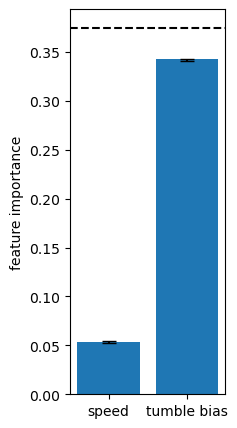

In [68]:
plt.figure(figsize=(2,5))
plt.bar(np.arange(len(mean)),mean,yerr = [mean-cil,ciu-mean],capsize=5)
plt.ylabel('feature importance')
plt.xticks([0,1],['speed','tumble bias'])
plt.axhline(r2_full,c='k',ls='--')
plt.ylim(0,)
# plt.savefig('feat_import_speed_tbias_phen.pdf')
plt.show()

In [69]:
r2_full,np.percentile(r2_fulls,2.5),np.percentile(r2_fulls,97.5)

(0.3749128950279499,
 np.float64(0.34806419206121053),
 np.float64(0.40584905961653167))

[[3.30115020e-001 8.08590129e-111]
 [1.92542300e-017 1.80503762e-094]]


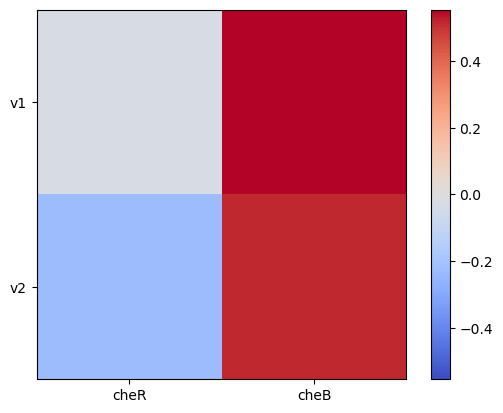

In [70]:
rho, pval = spearmanr(y_fit, X_fit, nan_policy='omit')

p = y_fit.shape[1]   # number of y variables
q = X_fit.shape[1]   # number of x variables

rho_cross = rho[:p, p:]
pval_cross = pval[:p, p:]

# Apply correction
pval_adj = fdr_bh(pval_cross)
print(pval_adj)
# plt.imshow(rho_cross,vmax=.6,vmin=-.6,cmap='coolwarm')
vmax = np.max(np.abs(rho_cross))
plt.imshow(rho_cross,vmax=vmax,vmin=-vmax,cmap='coolwarm')
# for i in range(p):
    # for j in range(p):
        # plt.text(j-.1,i+.01,'{:.2f}'.format(rho_cross[i,j]),fontsize=14)
plt.colorbar()
plt.xticks([0,1],['cheR','cheB'])
plt.yticks([0,1],['v1','v2'])
# plt.savefig('spearman_corr_cheR_cheB_v1_v2.png',dpi=300)

# plt.savefig('spearman_corr_cheR_cheB_v1_v2.pdf')

plt.show()

In [71]:
ci_low, ci_high, rho_boot = bootstrap_spearman_ci(
    y_fit,
    X_fit,
    n_boot=5000,
    confidence=0.95,
    random_state=42
)

for i in range(p):
    for j in range(q):
        print(
            f"{labels_y[i]} vs {labels_X[j]}: "
            f"rho = {rho_cross[i, j]:.2f}, "
            f"95% CI [{ci_low[i, j]:.2f}, {ci_high[i, j]:.2f}], "
            f"FDR p = {pval_adj[i, j]:.3g}"
        )

v1 vs cher: rho = -0.03, 95% CI [-0.08, 0.03], FDR p = 0.33
v1 vs cheb: rho = 0.55, 95% CI [0.52, 0.59], FDR p = 8.09e-111
v2 vs cher: rho = -0.23, 95% CI [-0.28, -0.18], FDR p = 1.93e-17
v2 vs cheb: rho = 0.52, 95% CI [0.48, 0.55], FDR p = 1.81e-94


# Predict speed and tumble bias from cheR and cheB

MSE per output: 21.233018685562644 +/- 1.2643086425325465
R²  per output: 0.3226609148006429 +/- 0.03785494781292002


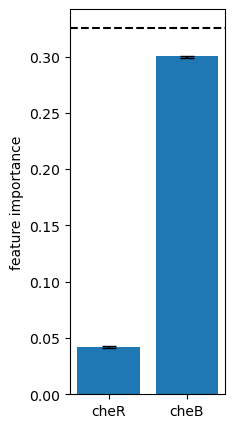

In [72]:
X = ma.vstack([ma.log10(rfp_cher),ma.log10(yfp_cheb)]).T

y =  ma.masked_invalid(Xp)
sel = np.logical_and(~np.any(X.mask,axis=1),~np.any(y.mask,axis=1))


X_fit = (X[sel]-X[sel].mean(axis=0))/X[sel].std(axis=0)
y = ma.vstack([speed_all,tbias]).T

y_fit = y[sel]

labels_X = ['cher','cheb']
labels_y = ['speed','tbias']


mses,r2s_full,coefs,importance,r2_full,r2_fulls = get_global_model_shuffled(X_fit,y_fit,n_boot=100)
coefs_mean = np.mean(coefs,axis=0)
plt.figure(figsize=(2,5))
mean = importance.mean(axis=1)
cil = np.percentile(importance,2.5,axis=1)
ciu = np.percentile(importance,97.5,axis=1)
plt.bar(np.arange(len(mean)),mean,yerr = [mean-cil,ciu-mean],capsize=5)
plt.ylabel('feature importance')
plt.xticks([0,1],['cheR','cheB'])
plt.axhline(r2_full,c='k',ls='--')
plt.ylim(0,)
# plt.savefig('feat_import_cheR_cheB_speed_tbias.pdf')

plt.show()


In [73]:
r2_full,np.percentile(r2_fulls,2.5),np.percentile(r2_fulls,97.5)

(0.32582611307117276,
 np.float64(0.2987288322031339),
 np.float64(0.35618946633046733))

[[2.29491128e-001 1.31254961e-073]
 [4.85712795e-017 1.09972088e-126]]


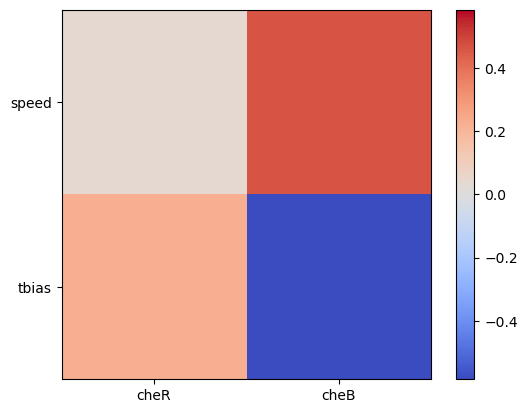

In [74]:
rho, pval = spearmanr(y_fit, X_fit, nan_policy='omit')

p = y_fit.shape[1]   # number of y variables
q = X_fit.shape[1]   # number of x variables

rho_cross = rho[:p, p:]
pval_cross = pval[:p, p:]

# Apply correction
pval_adj = fdr_bh(pval_cross)
print(pval_adj)
# plt.imshow(rho_cross,vmax=.6,vmin=-.6,cmap='coolwarm')
vmax = np.max(np.abs(rho_cross))
plt.imshow(rho_cross,vmax=vmax,vmin=-vmax,cmap='coolwarm')
# for i in range(p):
    # for j in range(p):
        # plt.text(j-.1,i+.01,'{:.2f}'.format(rho_cross[i,j]),fontsize=14)
plt.colorbar()
plt.xticks([0,1],['cheR','cheB'])
plt.yticks([0,1],['speed','tbias'])
# plt.savefig('spearman_corr_cheR_cheB_speed_tbias.png',dpi=300)
# plt.savefig('spearman_corr_cheR_cheB_speed_tbias.pdf')
plt.show()

In [75]:
ci_low, ci_high, rho_boot = bootstrap_spearman_ci(
    y_fit,
    X_fit,
    n_boot=5000,
    confidence=0.95,
    random_state=42
)

for i in range(p):
    for j in range(q):
        print(
            f"{labels_y[i]} vs {labels_X[j]}: "
            f"rho = {rho_cross[i, j]:.2f}, "
            f"95% CI [{ci_low[i, j]:.2f}, {ci_high[i, j]:.2f}], "
            f"FDR p = {pval_adj[i, j]:.3g}"
        )

speed vs cher: rho = 0.03, 95% CI [-0.02, 0.09], FDR p = 0.229
speed vs cheb: rho = 0.46, 95% CI [0.42, 0.50], FDR p = 1.31e-73
tbias vs cher: rho = 0.22, 95% CI [0.18, 0.27], FDR p = 4.86e-17
tbias vs cheb: rho = -0.59, 95% CI [-0.62, -0.55], FDR p = 1.1e-126


# Rotated axis

## Along mutant

In [81]:
idx = np.where(dataset_idx == 0)[0]
Y = Xp[idx,:2]
Y = Y - Y.mean(axis=0)
cov = np.cov(Y.T)
eigvals,eigvecs = np.linalg.eig(cov)
y_proj = -Y.dot(eigvecs) # sign of eigenvectors may be flipped with respect to the paper figures, but directions remain
X = ma.vstack([speed_all,tbias]).T
print(eigvals[0]/eigvals[1])
X_fit = X[idx]

X_fit = (X_fit-X_fit.mean(axis=0))/X_fit.std(axis=0)

2.296377707156456


MSE per output: 0.2651817720749533 +/- 0.006444181588882389
R²  per output: 0.6699979358932777 +/- 0.004611089923762041


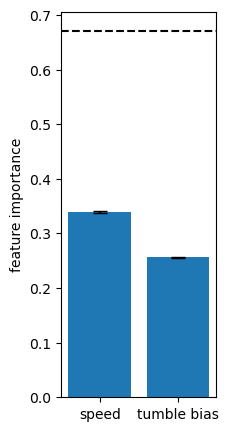

In [82]:
mses,r2s_full,coefs,importance,r2_full,r2_fulls = get_global_model_shuffled(X_fit,y_proj,n_boot=100)
plt.show()
plt.figure(figsize=(2,5))
mean = importance.mean(axis=1)
cil = np.percentile(importance,2.5,axis=1)
ciu = np.percentile(importance,97.5,axis=1)
plt.bar(np.arange(len(mean)),mean,yerr = [mean-cil,ciu-mean],capsize=5)
plt.ylabel('feature importance')
plt.xticks([0,1],['speed','tumble bias'])
plt.axhline(r2_full,c='k',ls='--')
plt.ylim(0,)
plt.ylim(0,)
# plt.savefig('feat_import_cheR_cheB_speed_tbias.pdf')

plt.show()

In [83]:
r2_full,np.percentile(r2_fulls,2.5),np.percentile(r2_fulls,97.5)

(0.6713321216092027,
 np.float64(0.6542829259801046),
 np.float64(0.6905467776779747))

[[8.23203755e-117 0.00000000e+000]
 [1.12337287e-128 1.16610269e-017]]


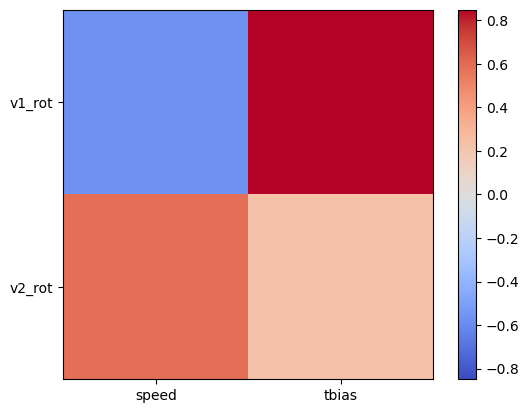

In [84]:
rho, pval = spearmanr(y_proj, X_fit, nan_policy='omit')

p = y_fit.shape[1]   # number of y variables
q = X_fit.shape[1]   # number of x variables

rho_cross = rho[:p, p:]
pval_cross = pval[:p, p:]

# Apply correction
pval_adj = fdr_bh(pval_cross)
print(pval_adj)

# plt.imshow(rho_cross,vmax=.9,vmin=-.9,cmap='coolwarm')
vmax = np.max(np.abs(rho_cross))
plt.imshow(rho_cross,vmax=vmax,vmin=-vmax,cmap='coolwarm')
# for i in range(p):
    # for j in range(p):
        # plt.text(j-.1,i+.01,'{:.2f}'.format(rho_cross[i,j]),fontsize=14)
plt.xticks([0,1],['speed','tbias'])
plt.yticks([0,1],['v1_rot','v2_rot'])
plt.colorbar()
# plt.savefig('spearman_corr_speed_tbias_v1_v2_rot_mutant.png',dpi=300)
# plt.savefig('spearman_corr_speed_tbias_v1_v2_rot_mutant.pdf')
plt.show()

In [85]:
ci_low, ci_high, rho_boot = bootstrap_spearman_ci(
    y_proj,
    X_fit,
    n_boot=5000,
    confidence=0.95,
    random_state=42
)

for i in range(p):
    for j in range(q):
        print(
            f"{labels_y[i]} vs {labels_X[j]}: "
            f"rho = {rho_cross[i, j]:.2f}, "
            f"95% CI [{ci_low[i, j]:.2f}, {ci_high[i, j]:.2f}], "
            f"FDR p = {pval_adj[i, j]:.3g}"
        )

speed vs cher: rho = -0.57, 95% CI [-0.61, -0.52], FDR p = 8.23e-117
speed vs cheb: rho = 0.85, 95% CI [0.83, 0.86], FDR p = 0
tbias vs cher: rho = 0.59, 95% CI [0.55, 0.62], FDR p = 1.12e-128
tbias vs cheb: rho = 0.23, 95% CI [0.18, 0.28], FDR p = 1.17e-17


## Along WT

In [86]:
idx = np.where(dataset_idx == 1)[0]
Y = Xp[idx,:2]
Y = Y - Y.mean(axis=0)
cov = np.cov(Y.T)
eigvals,eigvecs = np.linalg.eig(cov) 
print(eigvals[0]/eigvals[1])
print(eigvals)
y_proj = -Y.dot(eigvecs)
X = ma.vstack([speed_all,tbias]).T

X_fit = X[idx]

X_fit = (X_fit-X_fit.mean(axis=0))/X_fit.std(axis=0)

1.6222812093595167
[0.66176703 0.40792375]


MSE per output: 0.24900149271318894 +/- 0.005752954681572403
R²  per output: 0.48734608946037133 +/- 0.014846815154225014


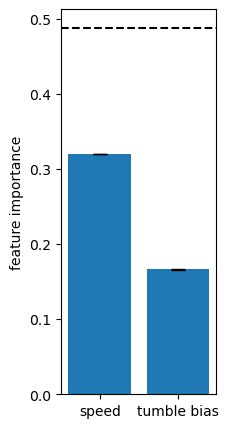

In [87]:
mses,r2s_full,coefs,importance,r2_full,r2_fulls = get_global_model_shuffled(X_fit,y_proj,n_boot=100)
plt.figure(figsize=(2,5))
mean = importance.mean(axis=1)
cil = np.percentile(importance,2.5,axis=1)
ciu = np.percentile(importance,97.5,axis=1)
plt.bar(np.arange(len(mean)),mean,yerr = [mean-cil,ciu-mean],capsize=5)
plt.ylabel('feature importance')
plt.xticks([0,1],['speed','tumble bias'])
plt.axhline(r2_full,c='k',ls='--')
plt.ylim(0,)

plt.ylim(0,)
# plt.savefig('feat_import_cheR_cheB_speed_tbias.pdf')

plt.show()

In [88]:
r2_full,np.percentile(r2_fulls,2.5),np.percentile(r2_fulls,97.5)

(0.4884430702628391,
 np.float64(0.4755157491549581),
 np.float64(0.5013707500156332))

[[0.00000000e+00 1.09253771e-82]
 [3.31204245e-22 0.00000000e+00]]


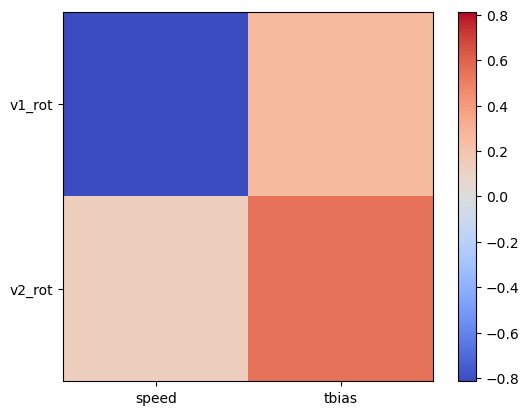

In [89]:
rho, pval = spearmanr(y_proj, X_fit, nan_policy='omit')

p = y_fit.shape[1]   # number of y variables
q = X_fit.shape[1]   # number of x variables

rho_cross = rho[:p, p:]
pval_cross = pval[:p, p:]

# Apply correction
pval_adj = fdr_bh(pval_cross)
print(pval_adj)
vmax = np.max(np.abs(rho_cross))
plt.imshow(rho_cross,vmax=vmax,vmin=-vmax,cmap='coolwarm')
# plt.imshow(rho_cross,vmax=.8,vmin=-.8,cmap='coolwarm')
# for i in range(p):
    # for j in range(p):
        # plt.text(j-.1,i+.01,'{:.2f}'.format(rho_cross[i,j]),fontsize=14)
plt.xticks([0,1],['speed','tbias'])
plt.yticks([0,1],['v1_rot','v2_rot'])
plt.colorbar()
# plt.savefig('spearman_corr_speed_tbias_v1_v2_rot_wt.png',dpi=300)
# plt.savefig('spearman_corr_speed_tbias_v1_v2_rot_wt.pdf')

plt.show()

In [90]:
ci_low, ci_high, rho_boot = bootstrap_spearman_ci(
    y_proj,
    X_fit,
    n_boot=5000,
    confidence=0.95,
    random_state=42
)

for i in range(p):
    for j in range(q):
        print(
            f"{labels_y[i]} vs {labels_X[j]}: "
            f"rho = {rho_cross[i, j]:.2f}, "
            f"95% CI [{ci_low[i, j]:.2f}, {ci_high[i, j]:.2f}], "
            f"FDR p = {pval_adj[i, j]:.3g}"
        )

speed vs cher: rho = -0.81, 95% CI [-0.83, -0.80], FDR p = 0
speed vs cheb: rho = 0.26, 95% CI [0.23, 0.28], FDR p = 1.09e-82
tbias vs cher: rho = 0.13, 95% CI [0.10, 0.16], FDR p = 3.31e-22
tbias vs cheb: rho = 0.55, 95% CI [0.53, 0.57], FDR p = 0
